# 📊 EDA — Painting Style Classification
Dataset: Painting Style Classification (Kaggle)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

DATASET_PATH = '../dataset2_painting/images/images'
TOP_N_ARTISTS = 10  # 🔥 ใช้เหมือน model

print('Dataset path:', DATASET_PATH)

Dataset path: ../dataset2_painting/images/images


In [2]:
# ── นับจำนวนรูปแต่ละ artist ─────────────────────────────────────
class_counts = {}

for artist in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, artist)
    if os.path.isdir(path):
        class_counts[artist] = len(os.listdir(path))

In [3]:
# เลือก Top N
top_artists = sorted(class_counts, key=class_counts.get, reverse=True)[:TOP_N_ARTISTS]

counts = {artist: class_counts[artist] for artist in top_artists}

df = pd.DataFrame.from_dict(counts, orient='index', columns=['count'])
df = df.sort_values(by='count', ascending=False)

print(df)
print(f'\nรวมทั้งหมด: {df["count"].sum()} รูป')

                       count
Vincent_van_Gogh         877
Edgar_Degas              702
Pablo_Picasso            439
Pierre-Auguste_Renoir    336
Albrecht_Durer           328
Paul_Gauguin             311
Francisco_Goya           291
Rembrandt                262
Alfred_Sisley            259
Titian                   255

รวมทั้งหมด: 4060 รูป


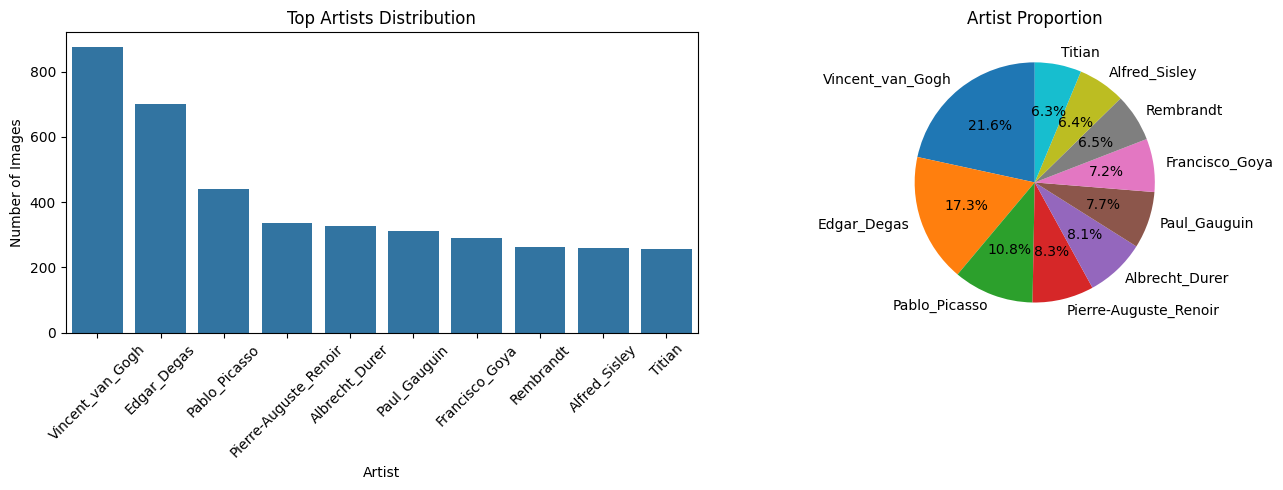

In [4]:
# ── Plot Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=df.index, y=df['count'], ax=axes[0])
axes[0].set_title('Top Artists Distribution')
axes[0].set_xlabel('Artist')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(df['count'], labels=df.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Artist Proportion')

plt.tight_layout()
plt.savefig('../models/painting_distribution.png')
plt.show()

In [5]:
# ── ตรวจสอบ Corrupt Images ───────────────────────────────────────
corrupt = []

for artist in top_artists:
    folder = os.path.join(DATASET_PATH, artist)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            Image.open(fpath).verify()
        except:
            corrupt.append(fpath)

print(f'รูป Corrupt: {len(corrupt)} ใบ')

# ลบ corrupt images
for f in corrupt:
    os.remove(f)

print(f'ลบแล้ว {len(corrupt)} ใบ')

รูป Corrupt: 0 ใบ
ลบแล้ว 0 ใบ


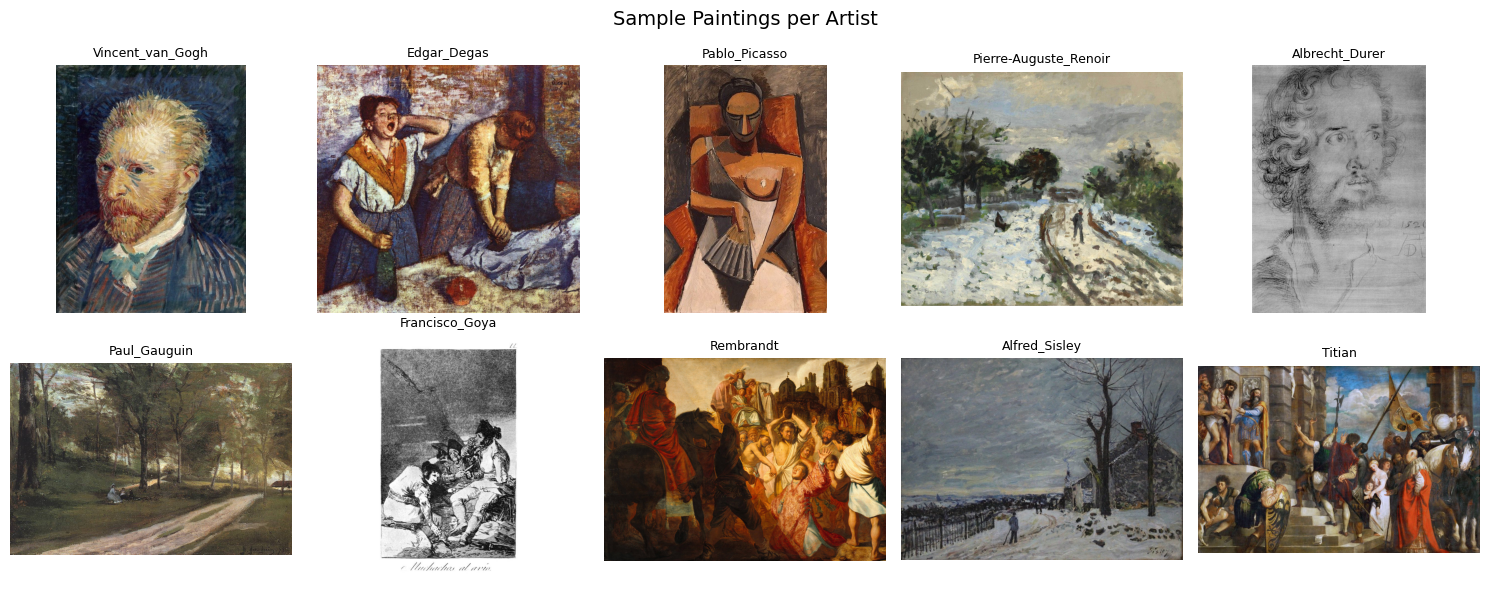

In [6]:
# ── ดูตัวอย่างภาพ ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, artist in zip(axes.flatten(), top_artists):
    folder = os.path.join(DATASET_PATH, artist)
    imgs = os.listdir(folder)

    if len(imgs) == 0:
        ax.set_title(f'{artist}\n(no data)')
        ax.axis('off')
        continue

    img = Image.open(os.path.join(folder, imgs[0])).convert('RGB')
    ax.imshow(img)
    ax.set_title(artist, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Paintings per Artist', fontsize=14)
plt.tight_layout()
plt.savefig('../models/painting_samples.png')
plt.show()

In [7]:
# ── ตรวจสอบขนาดรูป ───────────────────────────────────────────────
widths, heights = [], []

for artist in top_artists:
    folder = os.path.join(DATASET_PATH, artist)
    for fname in list(os.listdir(folder))[:30]:
        try:
            img = Image.open(os.path.join(folder, fname))
            widths.append(img.width)
            heights.append(img.height)
        except:
            pass

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

print('\nEDA เสร็จสิ้น — พร้อม train CNN')

Width  — min: 275, max: 3176, mean: 1006
Height — min: 308, max: 2402, mean: 1035

EDA เสร็จสิ้น — พร้อม train CNN
